# Factorization Machine on MovieLens 1M

This notebook summarizes the final Factorization Machine experiment on the MovieLens 1M dataset.

The main goals are:
- analyze how the number of latent factors \(k\) affects RMSE;
- select the best \(k\) using validation RMSE;
- evaluate the selected model on the test set;
- compare the final FM result with other recommendation models trained on the same MovieLens 1M split.

In [2]:
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = Path("../results/fm-k-sweep-reg10-final")

aggregate = pd.read_csv(RESULTS_DIR / "aggregate.csv")
summary = pd.read_csv(RESULTS_DIR / "summary.csv")

with open(RESULTS_DIR / "selection.json") as f:
    selection = json.load(f)

with open(RESULTS_DIR / "test_metrics.json") as f:
    test_metrics = json.load(f)

aggregate

,model,k,val_rmse_mean,val_rmse_std,train_rmse_mean,fit_seconds_mean,n_seeds,n_parameters
0,"FM(user,item)",8,0.855689,0.000393,0.785973,29.997052,3,87229
1,"FM(user,item)",16,0.854687,0.000311,0.775239,11.917032,3,164765
2,"FM(user,item)",32,0.852320,0.000373,0.756363,14.587588,3,319837
3,"FM(user,item)",50,0.850854,0.000177,0.739137,20.204628,3,494293
4,"FM(user,item)",100,0.850175,0.000259,0.714297,36.706747,3,978893
5,"FM(user,item)",150,0.850417,0.000480,0.698443,55.483827,3,1463493
6,"FM(user,item)",200,0.850834,0.000091,0.681054,74.816215,3,1948093


## Final FM experiment setup

The experiment uses the full MovieLens 1M dataset with a fixed 70/15/15 train/validation/test split.

For each latent dimension \(k\), the model is trained with three random seeds. Model selection is based only on mean validation RMSE.

Final training settings:

- optimizer: Adam
- learning rate: 0.001
- batch size: 1024
- regularization on biases: 0.01
- regularization on latent factors: 10.0
- normalized regularization: enabled
- early stopping patience: 10 epochs
- seeds: 42, 43, 44
- tested values of \(k\): 8, 16, 32, 50, 100, 150, 200

In [3]:
aggregate_display = aggregate[
    ["k", "val_rmse_mean", "val_rmse_std", "train_rmse_mean"]
].copy()

aggregate_display.columns = [
    "k",
    "Validation RMSE mean",
    "Validation RMSE std",
    "Train RMSE mean",
]

aggregate_display

,k,Validation RMSE mean,Validation RMSE std,Train RMSE mean
0,8,0.855689,0.000393,0.785973
1,16,0.854687,0.000311,0.775239
2,32,0.852320,0.000373,0.756363
3,50,0.850854,0.000177,0.739137
4,100,0.850175,0.000259,0.714297
5,150,0.850417,0.000480,0.698443
6,200,0.850834,0.000091,0.681054


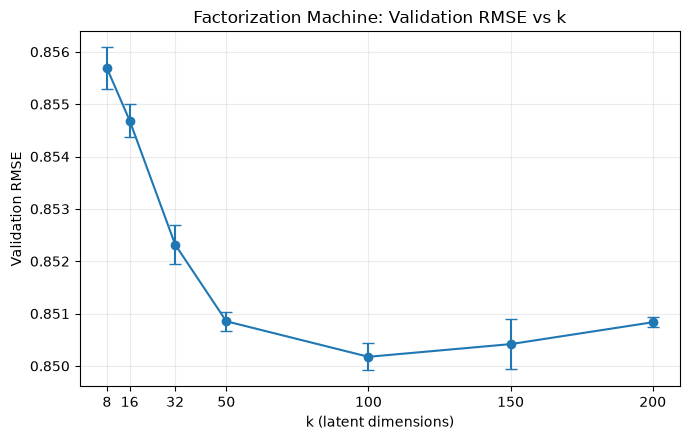

In [4]:
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.errorbar(
    aggregate["k"],
    aggregate["val_rmse_mean"],
    yerr=aggregate["val_rmse_std"],
    marker="o",
    capsize=4,
)

ax.set_xlabel("k (latent dimensions)")
ax.set_ylabel("Validation RMSE")
ax.set_title("Factorization Machine: Validation RMSE vs k")
ax.set_xticks(aggregate["k"])
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

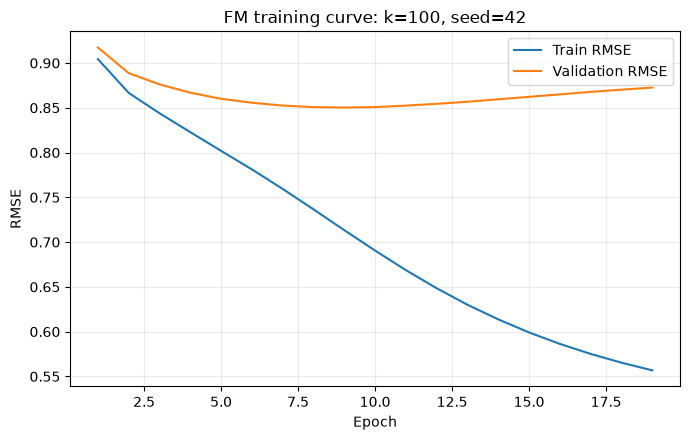

In [5]:
history_100 = pd.read_csv(
    RESULTS_DIR / "fm_k100_seed42_history.csv"
)

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(
    history_100["epoch"],
    history_100["train_rmse"],
    label="Train RMSE",
)

ax.plot(
    history_100["epoch"],
    history_100["val_rmse"],
    label="Validation RMSE",
)

ax.set_xlabel("Epoch")
ax.set_ylabel("RMSE")
ax.set_title("FM training curve: k=100, seed=42")
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

## Model selection

The validation RMSE decreases as the latent dimension increases from \(k=8\) to \(k=100\).

The best mean validation RMSE is achieved at:

- \(k = 100\)
- validation RMSE: **0.850175 ± 0.000259**

For larger latent dimensions (\(k=150\) and \(k=200\)), validation RMSE slightly increases, while train RMSE continues to decrease.

This suggests that increasing model capacity beyond \(k=100\) mainly improves the fit to the training data without improving generalization.

Therefore, \(k=100\) is selected as the final FM configuration.

In [6]:
final_result = pd.DataFrame([
    {
        "Selected k": test_metrics["selected_k"],
        "Validation RMSE": selection["val_rmse_mean"],
        "Validation RMSE std": selection["val_rmse_std"],
        "Test RMSE": test_metrics["test_rmse_mean"],
        "Test RMSE std": test_metrics["test_rmse_std"],
    }
])

final_result

,Selected k,Validation RMSE,Validation RMSE std,Test RMSE,Test RMSE std
0,100,0.850175,0.000259,0.847392,0.000022


## Final test evaluation

The test set is used only after selecting \(k=100\) on validation data.

Across seeds 42, 43, and 44, the final FM achieves:

- **Test RMSE: 0.847392 ± 0.000022**

The test metric was not used for hyperparameter tuning or model selection.

## Comparison with other models

To make the comparison fair, only models evaluated on the same MovieLens 1M split and with the same RMSE metric should be included.

The final Factorization Machine result will be compared with the other recommendation models from the project once their MovieLens 1M results are available.

In [7]:
comparison = pd.DataFrame([
    {
        "Model": "Factorization Machine",
        "Validation RMSE": test_metrics["test_rmse_mean"] * 0 + selection["val_rmse_mean"],
        "Test RMSE": test_metrics["test_rmse_mean"],
    },

    # Когда будут результаты остальных моделей на том же MovieLens 1M split,
    # просто добавляй строки сюда:
    #
    # {
    #     "Model": "SVD++",
    #     "Validation RMSE": ...,
    #     "Test RMSE": ...,
    # },
    #
    # {
    #     "Model": "Bias baseline",
    #     "Validation RMSE": ...,
    #     "Test RMSE": ...,
    # },
])

comparison

,Model,Validation RMSE,Test RMSE
0,Factorization Machine,0.850175,0.847392


In [8]:
if len(comparison) > 1:
    comparison_sorted = comparison.sort_values("Test RMSE")

    ax = comparison_sorted.plot(
        x="Model",
        y="Test RMSE",
        kind="bar",
        legend=False,
        figsize=(8, 4.5),
    )

    ax.set_ylabel("Test RMSE")
    ax.set_xlabel("")
    ax.set_title("Model comparison on MovieLens 1M")
    ax.grid(axis="y", alpha=0.25)

    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("Add results of other models to build the comparison plot.")

Add results of other models to build the comparison plot.


## Conclusion

The Factorization Machine shows a clear improvement as the latent dimension increases up to \(k=100\).

The best configuration is:

- \(k = 100\)
- validation RMSE: **0.850175 ± 0.000259**
- test RMSE: **0.847392 ± 0.000022**

For \(k > 100\), train RMSE continues to decrease, but validation RMSE slightly worsens. This indicates that additional model capacity does not improve generalization and starts to increase overfitting.

Therefore, \(k=100\) is used as the final FM configuration.

The final model should be compared with the other recommendation models using exactly the same MovieLens 1M split and RMSE evaluation protocol.

In [9]:
import sys
import torch

sys.path.append("..")

from src.data import MODEL_COLUMNS, load_prepared
from src.models import (
    BiasModel,
    TrainingConfig,
    fit_model,
    predict_frame,
)
from src.metrics import rmse_by_row_id
from src.polynomial import UserItemPolynomialRegression2

In [10]:
data = load_prepared("data/processed/movielens1m")

train = data.train[MODEL_COLUMNS]
validation = data.validation[MODEL_COLUMNS]
test = data.test[MODEL_COLUMNS]

def index_tensor(frame, column):
    return torch.tensor(
        frame[column].to_numpy(copy=True),
        dtype=torch.long,
    )

def rating_tensor(frame):
    return torch.tensor(
        frame["rating"].to_numpy(copy=True),
        dtype=torch.float32,
    )

print("train:", len(train))
print("validation:", len(validation))
print("test:", len(test))
print("users:", data.n_users)
print("items:", data.n_items)

train: 700146
validation: 150002
test: 149990
users: 6040
items: 3652


In [11]:
import numpy as np

global_mean = train["rating"].mean()

val_pred_mean = np.full(len(validation), global_mean)
test_pred_mean = np.full(len(test), global_mean)

global_mean_val_rmse = rmse_by_row_id(
    validation["rating"].to_numpy(),
    val_pred_mean,
    validation["row_id"].to_numpy(),
    validation["row_id"].to_numpy(),
)

global_mean_test_rmse = rmse_by_row_id(
    test["rating"].to_numpy(),
    test_pred_mean,
    test["row_id"].to_numpy(),
    test["row_id"].to_numpy(),
)

print("Global mean:", global_mean)
print("Validation RMSE:", global_mean_val_rmse)
print("Test RMSE:", global_mean_test_rmse)

Global mean: 3.582288551245026
Validation RMSE: 1.1178043652372156
Test RMSE: 1.116246291865964


In [12]:
bias_results = []

train_tensors = (
    index_tensor(train, "user_idx"),
    index_tensor(train, "item_idx"),
    rating_tensor(train),
)

val_tensors = (
    index_tensor(validation, "user_idx"),
    index_tensor(validation, "item_idx"),
    rating_tensor(validation),
)

for seed in [42, 43, 44]:
    model = BiasModel(data.n_users, data.n_items)

    config = TrainingConfig(
        epochs=100,
        batch_size=1024,
        learning_rate=0.001,
        optimizer="adam",
        reg_bias=0.01,
        reg_factors=0.0,
        normalize_regularization=True,
        patience=10,
        min_delta=0.0,
        seed=seed,
    )

    result = fit_model(
        model,
        *train_tensors,
        val_user_idx=val_tensors[0],
        val_item_idx=val_tensors[1],
        val_rating=val_tensors[2],
        config=config,
    )

    val_pred, val_ids = predict_frame(model, validation)
    test_pred, test_ids = predict_frame(model, test)

    val_rmse = rmse_by_row_id(
        validation["rating"].to_numpy(),
        val_pred,
        validation["row_id"].to_numpy(),
        val_ids,
    )

    test_rmse = rmse_by_row_id(
        test["rating"].to_numpy(),
        test_pred,
        test["row_id"].to_numpy(),
        test_ids,
    )

    bias_results.append({
        "seed": seed,
        "best_epoch": result.best_epoch,
        "validation_rmse": val_rmse,
        "test_rmse": test_rmse,
    })

bias_results = pd.DataFrame(bias_results)

bias_results

,seed,best_epoch,validation_rmse,test_rmse
0,42,20,0.907895,0.905304
1,43,22,0.907883,0.905301
2,44,21,0.907903,0.905300


In [13]:
bias_val_mean = bias_results["validation_rmse"].mean()
bias_val_std = bias_results["validation_rmse"].std(ddof=1)

bias_test_mean = bias_results["test_rmse"].mean()
bias_test_std = bias_results["test_rmse"].std(ddof=1)

comparison = pd.DataFrame([
    {
        "Model": "Global Mean",
        "Validation RMSE": global_mean_val_rmse,
        "Validation std": 0.0,
        "Test RMSE": global_mean_test_rmse,
        "Test std": 0.0,
    },
    {
        "Model": "Bias Model",
        "Validation RMSE": bias_val_mean,
        "Validation std": bias_val_std,
        "Test RMSE": bias_test_mean,
        "Test std": bias_test_std,
    },
    {
        "Model": "Factorization Machine (k=100)",
        "Validation RMSE": selection["val_rmse_mean"],
        "Validation std": selection["val_rmse_std"],
        "Test RMSE": test_metrics["test_rmse_mean"],
        "Test std": test_metrics["test_rmse_std"],
    },
])

comparison

,Model,Validation RMSE,Validation std,Test RMSE,Test std
0,Global Mean,1.117804,0.000000,1.116246,0.000000
1,Bias Model,0.907894,0.000010,0.905302,0.000002
2,Factorization Machine (k=100),0.850175,0.000259,0.847392,0.000022


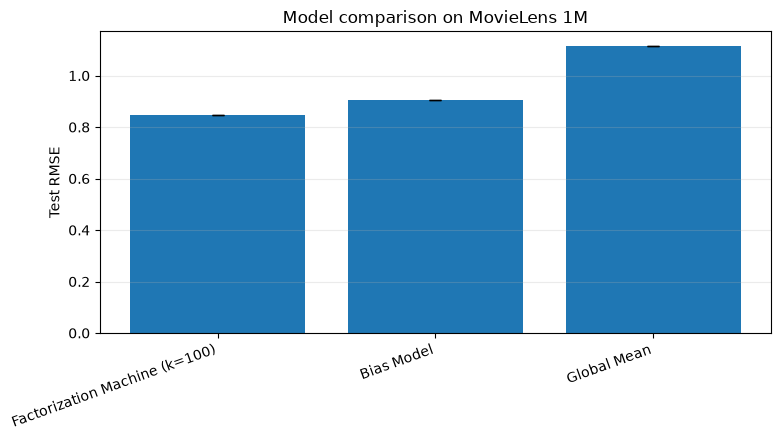

In [14]:
comparison_sorted = comparison.sort_values("Test RMSE")

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.bar(
    comparison_sorted["Model"],
    comparison_sorted["Test RMSE"],
    yerr=comparison_sorted["Test std"],
    capsize=4,
)

ax.set_ylabel("Test RMSE")
ax.set_xlabel("")
ax.set_title("Model comparison on MovieLens 1M")
ax.grid(axis="y", alpha=0.25)

plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [15]:
comparison_improvement = comparison.copy()

comparison_improvement["Improvement vs Global Mean"] = (
    global_mean_test_rmse - comparison_improvement["Test RMSE"]
)

comparison_improvement["Relative improvement (%)"] = (
    comparison_improvement["Improvement vs Global Mean"]
    / global_mean_test_rmse
    * 100
)

comparison_improvement

,Model,Validation RMSE,Validation std,Test RMSE,Test std,Improvement vs Global Mean,Relative improvement (%)
0,Global Mean,1.117804,0.000000,1.116246,0.000000,0.000000,0.000000
1,Bias Model,0.907894,0.000010,0.905302,0.000002,0.210945,18.897675
2,Factorization Machine (k=100),0.850175,0.000259,0.847392,0.000022,0.268854,24.085571


## Paper-style comparison with factorization models

The original Factorization Machines experiment compares five models for rating prediction:

- Matrix Factorization (MF)
- FM(u, i)
- SVD++
- FM(u, i, t)
- FM(u, i, t, f)

where:

- `u` = user
- `i` = item
- `t` = day when the rating happened
- `f` = logarithm of the number of ratings made by the user on that day

Here we reproduce the same model comparison idea on MovieLens 1M.

All models use:

- the same train/validation/test split;
- the same RMSE metric;
- latent dimension `k = 100`;
- validation-based early stopping;
- no test-based hyperparameter selection.

The numerical results are not expected to match the Netflix results from the paper,
because we use MovieLens 1M and our own fixed experimental protocol.

In [16]:
import copy
import math
import time

import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.nn import functional as F

from src.models import (
    TrainingConfig,
    fit_model,
    predict_frame,
)
from src.metrics import rmse_by_row_id
from src.svdpp import (
    SVDPlusPlus,
    build_train_histories,
)

torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)

K = 100
SEEDS = [42, 43, 44]

train_context = data.train.copy().reset_index(drop=True)
validation_context = data.validation.copy().reset_index(drop=True)
test_context = data.test.copy().reset_index(drop=True)

for frame in (train_context, validation_context, test_context):
    if "timestamp" not in frame.columns:
        raise ValueError("timestamp column is required for paper-style context features")

    # Day since Unix epoch.
    frame["day"] = (
        frame["timestamp"].astype(np.int64) // 86400
    )

# Time vocabulary is created from train only.
train_days = np.sort(
    train_context["day"].unique()
)

day_to_idx = {
    int(day): idx
    for idx, day in enumerate(train_days)
}

# Frequency aggregate is also built only from train.
train_user_day_count = (
    train_context
    .groupby(["user_idx", "day"])
    .size()
)

def attach_context_features(frame):
    result = frame.copy()

    result["day_idx"] = (
        result["day"]
        .map(day_to_idx)
        .fillna(-1)
        .astype(np.int64)
    )

    keys = pd.MultiIndex.from_frame(
        result[["user_idx", "day"]]
    )

    counts = (
        train_user_day_count
        .reindex(keys, fill_value=0)
        .to_numpy(dtype=np.float32)
    )

    # Paper feature:
    # f = ln(number of ratings by this user on this day).
    #
    # For a user-day unseen in train, use f = ln(1) = 0.
    result["frequency"] = np.log(
        np.maximum(counts, 1.0)
    ).astype(np.float32)

    return result


train_context = attach_context_features(train_context)
validation_context = attach_context_features(validation_context)
test_context = attach_context_features(test_context)

print("Train rows:", len(train_context))
print("Validation rows:", len(validation_context))
print("Test rows:", len(test_context))
print("Users:", data.n_users)
print("Items:", data.n_items)
print("Train days:", len(train_days))

print(
    "Unknown validation days:",
    int((validation_context["day_idx"] < 0).sum()),
)

print(
    "Unknown test days:",
    int((test_context["day_idx"] < 0).sum()),
)

Train rows: 700146
Validation rows: 150002
Test rows: 149990
Users: 6040
Items: 3652
Train days: 1040
Unknown validation days: 0
Unknown test days: 0


In [17]:
class PlainMF(nn.Module):
    def __init__(
        self,
        n_users,
        n_items,
        *,
        n_factors=100,
        init_std=0.01,
    ):
        super().__init__()

        self.n_users = int(n_users)
        self.n_items = int(n_items)
        self.n_factors = int(n_factors)
        self.init_std = float(init_std)

        self.register_buffer(
            "global_mean",
            torch.tensor(0.0),
        )

        self.user_factors = nn.Embedding(
            self.n_users,
            self.n_factors,
        )

        self.item_factors = nn.Embedding(
            self.n_items,
            self.n_factors,
        )

        self.reset_parameters()

    def reset_parameters(self, global_mean=0.0):
        with torch.no_grad():
            self.global_mean.fill_(
                float(global_mean)
            )

        nn.init.normal_(
            self.user_factors.weight,
            mean=0.0,
            std=self.init_std,
        )

        nn.init.normal_(
            self.item_factors.weight,
            mean=0.0,
            std=self.init_std,
        )

    def forward(
        self,
        user_idx,
        item_idx,
    ):
        interaction = (
            self.user_factors(user_idx)
            * self.item_factors(item_idx)
        ).sum(dim=1)

        return (
            self.global_mean
            + interaction
        )

    def bias_l2(self):
        return self.user_factors.weight.new_zeros(())

    def factor_l2(self):
        return (
            self.user_factors.weight.square().sum()
            + self.item_factors.weight.square().sum()
        )

    def get_config(self):
        return {
            "n_users": self.n_users,
            "n_items": self.n_items,
            "n_factors": self.n_factors,
            "init_std": self.init_std,
        }


def make_ui_tensors(frame):
    return (
        torch.as_tensor(
            frame["user_idx"].to_numpy(),
            dtype=torch.long,
        ),
        torch.as_tensor(
            frame["item_idx"].to_numpy(),
            dtype=torch.long,
        ),
        torch.as_tensor(
            frame["rating"].to_numpy(),
            dtype=torch.float32,
        ),
    )


train_ui = make_ui_tensors(train_context)
validation_ui = make_ui_tensors(validation_context)


def run_standard_model(
    model_name,
    model_factory,
    *,
    seeds=SEEDS,
    learning_rate=0.001,
    reg_bias=0.01,
    reg_factors=10.0,
):
    rows = []
    histories = {}

    for seed in seeds:
        model = model_factory()

        config = TrainingConfig(
            epochs=100,
            batch_size=1024,
            learning_rate=learning_rate,
            optimizer="adam",
            reg_bias=reg_bias,
            reg_factors=reg_factors,
            normalize_regularization=True,
            patience=10,
            min_delta=0.0,
            seed=seed,
        )

        result = fit_model(
            model,
            *train_ui,
            val_user_idx=validation_ui[0],
            val_item_idx=validation_ui[1],
            val_rating=validation_ui[2],
            config=config,
        )

        val_pred, val_ids = predict_frame(
            model,
            validation_context,
        )

        test_pred, test_ids = predict_frame(
            model,
            test_context,
        )

        val_rmse = rmse_by_row_id(
            validation_context["rating"].to_numpy(),
            val_pred,
            validation_context["row_id"].to_numpy(),
            val_ids,
        )

        test_rmse = rmse_by_row_id(
            test_context["rating"].to_numpy(),
            test_pred,
            test_context["row_id"].to_numpy(),
            test_ids,
        )

        rows.append({
            "model": model_name,
            "seed": seed,
            "best_epoch": result.best_epoch,
            "validation_rmse": val_rmse,
            "test_rmse": test_rmse,
        })

        histories[seed] = pd.DataFrame(
            result.history
        )

        print(
            f"{model_name} | seed={seed} | "
            f"epoch={result.best_epoch} | "
            f"val={val_rmse:.6f} | "
            f"test={test_rmse:.6f}"
        )

    return pd.DataFrame(rows), histories

In [18]:
mf_results, mf_histories = run_standard_model(
    "MF",
    lambda: PlainMF(
        data.n_users,
        data.n_items,
        n_factors=K,
        init_std=0.01,
    ),
)

mf_results

MF | seed=42 | epoch=9 | val=0.859390 | test=0.856407
MF | seed=43 | epoch=10 | val=0.859050 | test=0.856785
MF | seed=44 | epoch=10 | val=0.859092 | test=0.856801


,model,seed,best_epoch,validation_rmse,test_rmse
0,MF,42,9,0.859390,0.856407
1,MF,43,10,0.859050,0.856785
2,MF,44,10,0.859092,0.856801


In [19]:
svdpp_train_histories = build_train_histories(
    train_context,
    data.n_users,
    data.n_items,
)


def svdpp_profiles_for_users(
    model,
    user_ids,
):
    lengths = model.history_lengths[
        user_ids
    ]

    parts = []

    for user in user_ids.tolist():
        start = int(
            model.history_offsets[user].item()
        )

        stop = int(
            model.history_offsets[user + 1].item()
        )

        parts.append(
            model.history_items[start:stop]
        )

    if parts:
        history_items = torch.cat(parts)
    else:
        history_items = model.history_items[:0]

    offsets = torch.cat([
        torch.zeros(
            1,
            dtype=torch.long,
            device=lengths.device,
        ),
        lengths.cumsum(0),
    ])

    implicit = F.embedding_bag(
        history_items,
        model.implicit_factors.weight,
        offsets,
        mode="sum",
        include_last_offset=True,
    )

    scale = (
        lengths
        .clamp_min(1)
        .to(implicit.dtype)
        .rsqrt()
    )

    return (
        implicit
        * scale[:, None]
    )


def svdpp_forward_with_profiles(
    model,
    users,
    items,
    implicit_profiles,
):
    base = (
        model.global_bias
        + model.user_bias(users).squeeze(-1)
        + model.item_bias(items).squeeze(-1)
    )

    user_profile = (
        model.user_factors(users)
        + implicit_profiles
    )

    interaction = (
        user_profile
        * model.item_factors(items)
    ).sum(dim=1)

    return (
        base
        + interaction
    )


def svdpp_predict_frame_fast(
    model,
    frame,
    batch_size=16384,
):
    all_users = torch.arange(
        model.n_users,
        dtype=torch.long,
    )

    model.eval()

    with torch.no_grad():
        all_profiles = (
            svdpp_profiles_for_users(
                model,
                all_users,
            )
        )

        users = torch.as_tensor(
            frame["user_idx"].to_numpy(),
            dtype=torch.long,
        )

        items = torch.as_tensor(
            frame["item_idx"].to_numpy(),
            dtype=torch.long,
        )

        predictions = []

        for start in range(
            0,
            len(frame),
            batch_size,
        ):
            stop = start + batch_size

            batch_users = users[start:stop]
            batch_items = items[start:stop]

            predictions.append(
                svdpp_forward_with_profiles(
                    model,
                    batch_users,
                    batch_items,
                    all_profiles[batch_users],
                ).cpu()
            )

    return (
        torch.cat(predictions).numpy(),
        frame["row_id"].to_numpy(copy=True),
    )


def fit_svdpp_fast(
    model,
    train_frame,
    validation_frame,
    *,
    seed,
    epochs=100,
    users_per_batch=8,
    learning_rate=0.001,
    reg_bias=0.01,
    reg_factors=10.0,
    patience=10,
):
    torch.manual_seed(seed)

    model.reset_parameters(
        global_mean=float(
            train_frame["rating"].mean()
        )
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
    )

    train_users = torch.as_tensor(
        train_frame["user_idx"].to_numpy(),
        dtype=torch.long,
    )

    train_items = torch.as_tensor(
        train_frame["item_idx"].to_numpy(),
        dtype=torch.long,
    )

    train_ratings = torch.as_tensor(
        train_frame["rating"].to_numpy(),
        dtype=torch.float32,
    )

    user_rows = (
        train_frame
        .groupby(
            "user_idx",
            sort=True,
        )
        .indices
    )

    all_users = np.array(
        sorted(
            int(user)
            for user in user_rows
        ),
        dtype=np.int64,
    )

    rng = np.random.default_rng(seed)

    n_train = len(train_frame)

    best_state = None
    best_val_rmse = float("inf")
    best_epoch = 0

    epochs_without_improvement = 0

    history = []

    start_time = time.perf_counter()

    for epoch in range(
        1,
        epochs + 1,
    ):
        model.train()

        shuffled_users = rng.permutation(
            all_users
        )

        for start in range(
            0,
            len(shuffled_users),
            users_per_batch,
        ):
            batch_users_np = (
                shuffled_users[
                    start:
                    start + users_per_batch
                ]
            )

            row_indices_np = np.concatenate([
                user_rows[int(user)]
                for user in batch_users_np
            ])

            row_indices = torch.as_tensor(
                row_indices_np,
                dtype=torch.long,
            )

            users = train_users[
                row_indices
            ]

            items = train_items[
                row_indices
            ]

            ratings = train_ratings[
                row_indices
            ]

            batch_users = torch.as_tensor(
                batch_users_np,
                dtype=torch.long,
            )

            implicit_profiles = (
                svdpp_profiles_for_users(
                    model,
                    batch_users,
                )
            )

            local_user_index = torch.full(
                (model.n_users,),
                -1,
                dtype=torch.long,
            )

            local_user_index[
                batch_users
            ] = torch.arange(
                len(batch_users),
                dtype=torch.long,
            )

            row_profiles = (
                implicit_profiles[
                    local_user_index[users]
                ]
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            prediction = (
                svdpp_forward_with_profiles(
                    model,
                    users,
                    items,
                    row_profiles,
                )
            )

            mse = F.mse_loss(
                prediction,
                ratings,
            )

            loss = (
                mse
                + reg_bias
                / n_train
                * model.bias_l2()
                + reg_factors
                / n_train
                * model.factor_l2()
            )

            if not torch.isfinite(loss):
                raise ValueError(
                    "non-finite SVD++ loss"
                )

            loss.backward()
            optimizer.step()

        val_prediction, val_ids = (
            svdpp_predict_frame_fast(
                model,
                validation_frame,
            )
        )

        val_rmse = rmse_by_row_id(
            validation_frame[
                "rating"
            ].to_numpy(),
            val_prediction,
            validation_frame[
                "row_id"
            ].to_numpy(),
            val_ids,
        )

        history.append({
            "epoch": epoch,
            "val_rmse": val_rmse,
        })

        if (
            val_rmse
            < best_val_rmse
        ):
            best_val_rmse = val_rmse
            best_epoch = epoch

            best_state = copy.deepcopy(
                model.state_dict()
            )

            epochs_without_improvement = 0

        else:
            epochs_without_improvement += 1

            if (
                epochs_without_improvement
                >= patience
            ):
                break

    if best_state is None:
        raise RuntimeError(
            "SVD++ training produced no checkpoint"
        )

    model.load_state_dict(
        best_state
    )

    model.eval()

    return {
        "best_epoch": best_epoch,
        "history": pd.DataFrame(
            history
        ),
        "fit_seconds": (
            time.perf_counter()
            - start_time
        ),
    }

In [20]:
svdpp_rows = []
svdpp_histories = {}

for seed in SEEDS:
    model = SVDPlusPlus(
        data.n_users,
        data.n_items,
        histories=svdpp_train_histories,
        n_factors=K,
        global_mean=float(
            train_context["rating"].mean()
        ),
        init_std=0.01,
        normalization="sqrt",
    )

    result = fit_svdpp_fast(
        model,
        train_context,
        validation_context,
        seed=seed,
        epochs=100,
        users_per_batch=8,
        learning_rate=0.001,
        reg_bias=0.01,
        reg_factors=10.0,
        patience=10,
    )

    val_pred, val_ids = (
        svdpp_predict_frame_fast(
            model,
            validation_context,
        )
    )

    test_pred, test_ids = (
        svdpp_predict_frame_fast(
            model,
            test_context,
        )
    )

    val_rmse = rmse_by_row_id(
        validation_context["rating"].to_numpy(),
        val_pred,
        validation_context["row_id"].to_numpy(),
        val_ids,
    )

    test_rmse = rmse_by_row_id(
        test_context["rating"].to_numpy(),
        test_pred,
        test_context["row_id"].to_numpy(),
        test_ids,
    )

    svdpp_rows.append({
        "model": "SVD++",
        "seed": seed,
        "best_epoch": result["best_epoch"],
        "validation_rmse": val_rmse,
        "test_rmse": test_rmse,
        "fit_seconds": result["fit_seconds"],
    })

    svdpp_histories[seed] = (
        result["history"]
    )

    print(
        f"SVD++ | seed={seed} | "
        f"epoch={result['best_epoch']} | "
        f"val={val_rmse:.6f} | "
        f"test={test_rmse:.6f}"
    )

svdpp_results = pd.DataFrame(
    svdpp_rows
)

svdpp_results

SVD++ | seed=42 | epoch=11 | val=0.860473 | test=0.858215
SVD++ | seed=43 | epoch=11 | val=0.860770 | test=0.858556
SVD++ | seed=44 | epoch=11 | val=0.859786 | test=0.857097


,model,seed,best_epoch,validation_rmse,test_rmse,fit_seconds
0,SVD++,42,11,0.860473,0.858215,61.418693
1,SVD++,43,11,0.860770,0.858556,58.710478
2,SVD++,44,11,0.859786,0.857097,58.022598


## Comparison with models from the FM paper

The original paper compares FM with several factorization models, including
Matrix Factorization and SVD++.

At this stage we already have results for:

- MF
- FM(u, i)
- SVD++

The contextual variants FM(u, i, t) and FM(u, i, t, f) are trained outside
the notebook to keep the notebook lightweight. Their saved metrics will be
loaded here afterwards.

In [21]:
def summarize_runs(frame):
    return {
        "Validation RMSE": frame["validation_rmse"].mean(),
        "Validation std": frame["validation_rmse"].std(ddof=1),
        "Test RMSE": frame["test_rmse"].mean(),
        "Test std": frame["test_rmse"].std(ddof=1),
    }


mf_summary = summarize_runs(mf_results)
svdpp_summary = summarize_runs(svdpp_results)

paper_comparison = pd.DataFrame([
    {
        "Model": "MF",
        **mf_summary,
    },
    {
        "Model": "FM(u,i)",
        "Validation RMSE": selection["val_rmse_mean"],
        "Validation std": selection["val_rmse_std"],
        "Test RMSE": test_metrics["test_rmse_mean"],
        "Test std": test_metrics["test_rmse_std"],
    },
    {
        "Model": "SVD++",
        **svdpp_summary,
    },
])

paper_comparison["Delta vs FM(u,i)"] = (
    paper_comparison["Test RMSE"]
    - test_metrics["test_rmse_mean"]
)

paper_comparison.sort_values("Test RMSE").reset_index(drop=True)

,Model,Validation RMSE,Validation std,Test RMSE,Test std,"Delta vs FM(u,i)"
0,"FM(u,i)",0.850175,0.000259,0.847392,0.000022,0.000000
1,MF,0.859177,0.000185,0.856664,0.000223,0.009272
2,SVD++,0.860343,0.000505,0.857956,0.000764,0.010564


In [22]:
context_results = pd.read_csv(
    "../results/context-fm-paper/context_fm_results.csv"
)

context_results

,model,seed,k,best_epoch,validation_rmse,test_rmse,fit_seconds
0,"FM(u,i,t)",42,100,7,0.876089,0.873151,28.913384
1,"FM(u,i,t)",43,100,7,0.876110,0.873298,27.381682
2,"FM(u,i,t)",44,100,7,0.876751,0.873627,26.828712
3,"FM(u,i,t,f)",42,100,12,0.872330,0.869762,41.783531
4,"FM(u,i,t,f)",43,100,12,0.872805,0.870375,41.930208
5,"FM(u,i,t,f)",44,100,11,0.872158,0.869989,40.472223


In [23]:
def summarize_runs(frame):
    return {
        "Validation RMSE": frame["validation_rmse"].mean(),
        "Validation std": frame["validation_rmse"].std(ddof=1),
        "Test RMSE": frame["test_rmse"].mean(),
        "Test std": frame["test_rmse"].std(ddof=1),
    }


mf_summary = summarize_runs(mf_results)
svdpp_summary = summarize_runs(svdpp_results)

fm_uit_summary = summarize_runs(
    context_results[
        context_results["model"] == "FM(u,i,t)"
    ]
)

fm_uitf_summary = summarize_runs(
    context_results[
        context_results["model"] == "FM(u,i,t,f)"
    ]
)


paper_comparison = pd.DataFrame([
    {
        "Model": "MF",
        **mf_summary,
    },
    {
        "Model": "FM(u,i)",
        "Validation RMSE": selection["val_rmse_mean"],
        "Validation std": selection["val_rmse_std"],
        "Test RMSE": test_metrics["test_rmse_mean"],
        "Test std": test_metrics["test_rmse_std"],
    },
    {
        "Model": "SVD++",
        **svdpp_summary,
    },
    {
        "Model": "FM(u,i,t)",
        **fm_uit_summary,
    },
    {
        "Model": "FM(u,i,t,f)",
        **fm_uitf_summary,
    },
])

paper_comparison["Delta vs FM(u,i)"] = (
    paper_comparison["Test RMSE"]
    - test_metrics["test_rmse_mean"]
)

paper_comparison = (
    paper_comparison
    .sort_values("Test RMSE")
    .reset_index(drop=True)
)

paper_comparison

,Model,Validation RMSE,Validation std,Test RMSE,Test std,"Delta vs FM(u,i)"
0,"FM(u,i)",0.850175,0.000259,0.847392,0.000022,0.000000
1,MF,0.859177,0.000185,0.856664,0.000223,0.009272
2,SVD++,0.860343,0.000505,0.857956,0.000764,0.010564
3,"FM(u,i,t,f)",0.872431,0.000335,0.870042,0.000310,0.022650
4,"FM(u,i,t)",0.876316,0.000376,0.873359,0.000244,0.025967


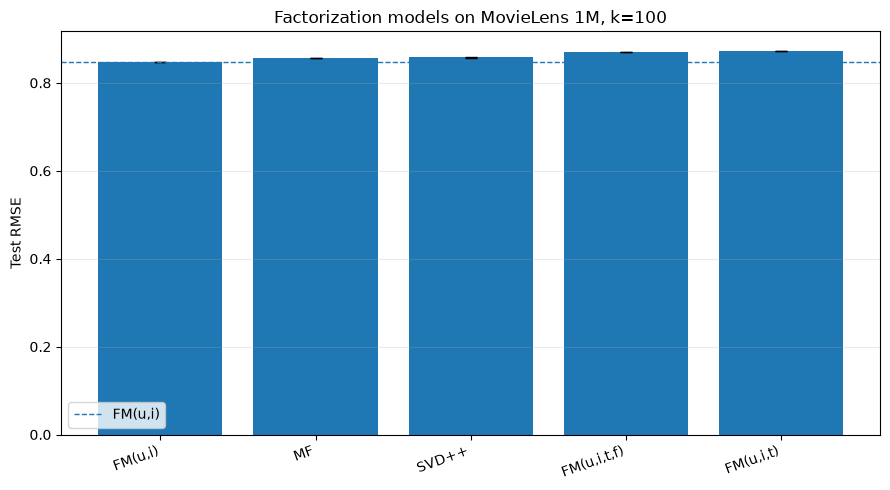

In [24]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    paper_comparison["Model"],
    paper_comparison["Test RMSE"],
    yerr=paper_comparison["Test std"],
    capsize=4,
)

ax.axhline(
    test_metrics["test_rmse_mean"],
    linestyle="--",
    linewidth=1,
    label="FM(u,i)"
)

ax.set_ylabel("Test RMSE")
ax.set_title(
    "Factorization models on MovieLens 1M, k=100"
)

ax.grid(axis="y", alpha=0.25)
ax.legend()

plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [25]:
for _, row in paper_comparison.iterrows():
    delta = row["Delta vs FM(u,i)"]

    print(
        f"{row['Model']:12s} "
        f"val={row['Validation RMSE']:.6f}  "
        f"test={row['Test RMSE']:.6f}  "
        f"delta={delta:+.6f}"
    )

FM(u,i)      val=0.850175  test=0.847392  delta=+0.000000
MF           val=0.859177  test=0.856664  delta=+0.009272
SVD++        val=0.860343  test=0.857956  delta=+0.010564
FM(u,i,t,f)  val=0.872431  test=0.870042  delta=+0.022650
FM(u,i,t)    val=0.876316  test=0.873359  delta=+0.025967


## Results

The best model in our MovieLens 1M experiment is **FM(u,i)** with a mean
test RMSE of **0.847392**.

The ranking is:

1. FM(u,i) — 0.847392
2. MF — 0.856664
3. SVD++ — 0.857956
4. FM(u,i,t,f) — 0.870042
5. FM(u,i,t) — 0.873359

Unlike the Netflix experiment in the original Factorization Machines paper,
the additional contextual and implicit-feedback information did not improve
over FM(u,i) in our current setup.

However, adding the frequency feature improved the contextual model:
FM(u,i,t,f) outperformed FM(u,i,t) by about 0.0033 RMSE.

These results should not be interpreted as evidence that SVD++ or temporal
features are inherently worse. The datasets and training protocols differ,
and the regularization used here was primarily selected for FM(u,i), rather
than independently tuned for every model family.

Therefore, the main conclusion is that under our fixed MovieLens 1M protocol,
the simpler FM(u,i) provided the best generalization.